In [1]:
# getting time of day variable

import xarray as xr 

nam = xr.open_dataset('/D4/data/gvaillant/NAM-2019-netcdf/01/domnys-nam_218_20190101_0000_000.nc')

nam

<xarray.Dataset> Size: 9MB
Dimensions:                                           (time: 1, y: 67, x: 71)
Coordinates:
  * y                                                 (y) float64 536B 0.0 .....
  * x                                                 (x) float64 568B 0.0 .....
    latitude                                          (y, x) float64 38kB ...
    longitude                                         (y, x) float64 38kB ...
  * time                                              (time) datetime64[ns] 8B ...
Data variables: (12/445)
    PRMSL_meansealevel                                (time, y, x) float32 19kB ...
    REFD_1hybridlevel                                 (time, y, x) float32 19kB ...
    REFC_entireatmosphere_consideredasasinglelayer_   (time, y, x) float32 19kB ...
    VIS_surface                                       (time, y, x) float32 19kB ...
    VIS_cloudtop                                      (time, y, x) float32 19kB ...
    BMIXL_1hybridlevel                                (time, y, x) float32 19kB ...
    ...                                                ...
    LHTFL_surface                                     (time, y, x) float32 19kB ...
    TCDC_entireatmosphere_consideredasasinglelayer_   (time, y, x) float32 19kB ...
    DSWRF_surface                                     (time, y, x) float32 19kB ...
    DLWRF_surface                                     (time, y, x) float32 19kB ...
    USWRF_surface                                     (time, y, x) float32 19kB ...
    ULWRF_surface                                     (time, y, x) float32 19kB ...
Attributes:
    Conventions:          CF-1.0
    History:              created by wgrib2
    GRIB2_grid_template:  30

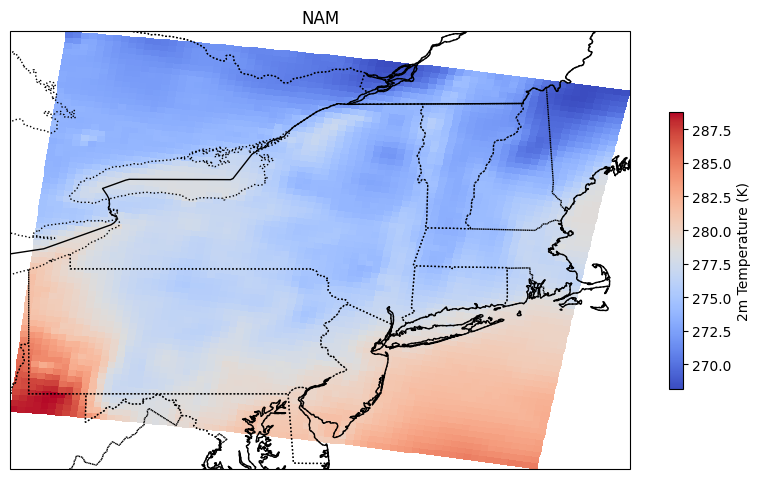

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

t_idx = 0
nam_lon = nam['longitude'].values
nam_lat = nam['latitude'].values
nam_t2 = nam['TMP_2maboveground'].values
nam_t2 = nam_t2[t_idx, :, :]

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot data
im = ax.pcolormesh(nam_lon, nam_lat, nam_t2, transform=ccrs.PlateCarree(), cmap='coolwarm')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.6)
cbar.set_label('2m Temperature (K)')

# Title
plt.title('NAM')

plt.show()

In [2]:
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')

nam_train

<xarray.Dataset> Size: 121MB
Dimensions:    (time: 2697, y: 40, x: 40)
Coordinates:
  * y          (y) float64 320B 1.219e+04 2.438e+04 ... 4.754e+05 4.876e+05
  * x          (x) float64 320B 3.292e+05 3.413e+05 ... 7.924e+05 8.046e+05
    latitude   (y, x) float64 13kB ...
    longitude  (y, x) float64 13kB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Data variables:
    T2         (time, y, x) float32 17MB ...
    PSFC       (time, y, x) float32 17MB ...
    U10        (time, y, x) float32 17MB ...
    V10        (time, y, x) float32 17MB ...
    SWDOWN     (time, y, x) float32 17MB ...
    PBLH       (time, y, x) float32 17MB ...
    HGT        (time, y, x) float32 17MB ...
Attributes:
    Conventions:          CF-1.0
    History:              created by wgrib2
    GRIB2_grid_template:  30

In [3]:
import xarray as xr
from geopy.distance import geodesic
import numpy as np

# Load NAM dataset
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')

# Extract lat/lon (variable names may differ; check your dataset)
lat = nam_train['latitude'].values  # shape: (y, x)
lon = nam_train['longitude'].values

# Distance arrays
dist_x = np.zeros_like(lat)  # east-west distance (m)
dist_y = np.zeros_like(lat)  # north-south distance (m)

# Compute east-west spacing
for i in range(lat.shape[0]):
    for j in range(lat.shape[1]-1):
        dist_x[i, j] = geodesic((lat[i, j], lon[i, j]), (lat[i, j+1], lon[i, j+1])).meters

# Compute north-south spacing
for i in range(lat.shape[0]-1):
    for j in range(lat.shape[1]):
        dist_y[i, j] = geodesic((lat[i, j], lon[i, j]), (lat[i+1, j], lon[i+1, j])).meters

# Average grid spacing
mean_dx = np.mean(dist_x)
mean_dy = np.mean(dist_y)

print(f"Average NAM grid spacing (east-west): {mean_dx:.2f} m")
print(f"Average NAM grid spacing (north-south): {mean_dy:.2f} m")


Average NAM grid spacing (east-west): 11431.08 m
Average NAM grid spacing (north-south): 11389.53 m


In [5]:
uwrf2 = xr.open_dataset('/D4/data/gvaillant/uwrf/01/01/d02_files/wrfout_d02_2019-01-01_00:00:00')

uwrf2

<xarray.Dataset> Size: 369MB
Dimensions:                (Time: 1, south_north: 120, west_east: 120,
                            bottom_top: 50, bottom_top_stag: 51,
                            soil_layers_stag: 4, west_east_stag: 121,
                            south_north_stag: 121, urban_layers_stag: 5400)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 58kB ...
    XLONG                  (Time, south_north, west_east) float32 58kB ...
    XTIME                  (Time) datetime64[ns] 8B ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 58kB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 58kB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 58kB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 58kB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag,
                                urban_layers_stag
Data variables: (12/162)
    Times                  (Time) |S19 19B ...
    LU_INDEX               (Time, south_north, west_east) float32 58kB ...
    ZNU                    (Time, bottom_top) float32 200B ...
    ZNW                    (Time, bottom_top_stag) float32 204B ...
    ZS                     (Time, soil_layers_stag) float32 16B ...
    DZS                    (Time, soil_layers_stag) float32 16B ...
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 58kB ...
    PC                     (Time, south_north, west_east) float32 58kB ...
    LANDMASK               (Time, south_north, west_east) float32 58kB ...
    LAKEMASK               (Time, south_north, west_east) float32 58kB ...
    SST                    (Time, south_north, west_east) float32 58kB ...
    SST_INPUT              (Time, south_north, west_east) float32 58kB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

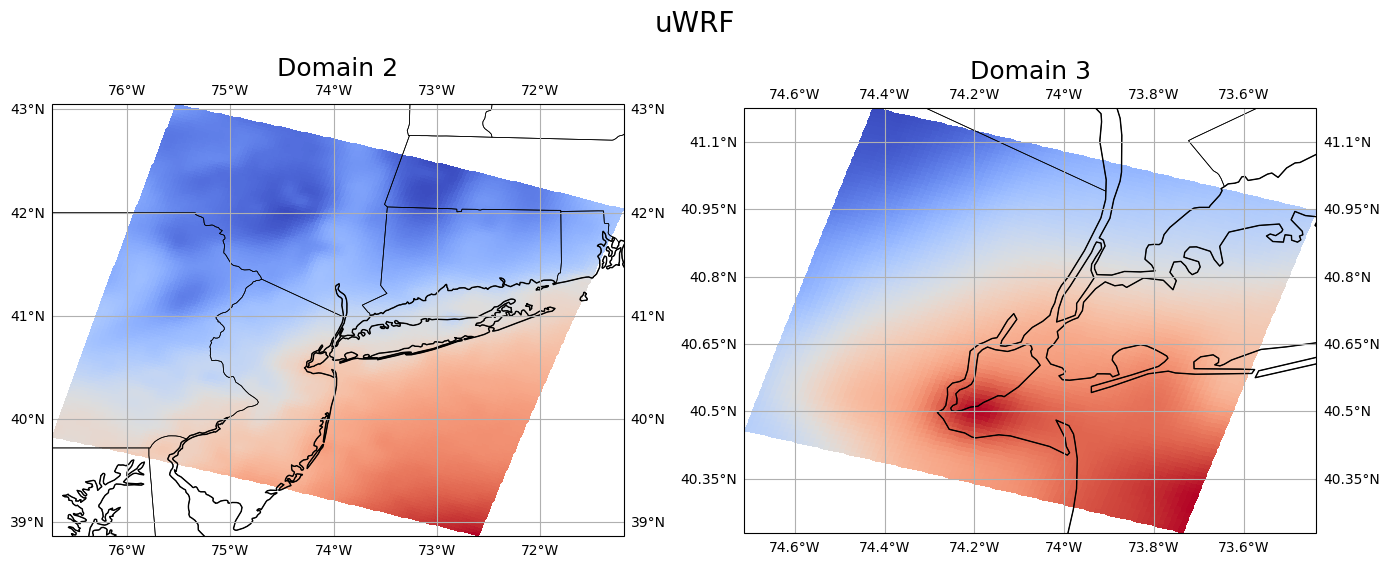

In [41]:
#visualizing original uWRF for domain 2:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Domain 2 Information ----- #
uwrf2 = xr.open_dataset('/D4/data/gvaillant/uwrf/01/01/d02_files/wrfout_d02_2019-01-01_00:00:00')
uwrf2_lat = uwrf2['XLAT'].sel(Time=0).values
uwrf2_lon = uwrf2['XLONG'].sel(Time=0).values
uwrf2_t2 = uwrf2['T2'].sel(Time=0).values

# ---- Domain 3 Information ----- #
uwrf3 = xr.open_dataset('/D4/data/gvaillant/uwrf/01/01/d03_files/wrfout_d03_2019-01-01_00:00:00')
uwrf3_lat = uwrf3['XLAT'].sel(Time=0).values
uwrf3_lon = uwrf3['XLONG'].sel(Time=0).values
uwrf3_t2 = uwrf3['T2'].sel(Time=0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# uWRF Plot
d2 = axes[0].pcolormesh(uwrf2_lon, uwrf2_lat, uwrf2_t2, cmap='coolwarm', transform=ccrs.PlateCarree())
axes[0].set_title("Domain 2", fontsize=18)
axes[0].add_feature(cfeature.COASTLINE)
axes[0].add_feature(cfeature.BORDERS, linestyle=':')
axes[0].add_feature(cfeature.STATES, linewidth=0.5)
axes[0].gridlines(draw_labels=True)

d3 = axes[1].pcolormesh(uwrf3_lon, uwrf3_lat, uwrf3_t2, cmap='coolwarm', transform=ccrs.PlateCarree())
axes[1].set_title("Domain 3", fontsize=18)
axes[1].add_feature(cfeature.COASTLINE)
axes[1].add_feature(cfeature.BORDERS, linestyle=':')
axes[1].add_feature(cfeature.STATES, linewidth=0.5)
axes[1].gridlines(draw_labels=True)

fig.suptitle('uWRF', fontsize=20)
fig.tight_layout()

In [42]:
uwrf3 = xr.open_dataset('/D4/data/gvaillant/uwrf/01/01/d03_files/wrfout_d03_2019-01-01_00:00:00')

uwrf3

<xarray.Dataset> Size: 175MB
Dimensions:                (Time: 1, south_north: 81, west_east: 84,
                            bottom_top: 50, bottom_top_stag: 51,
                            soil_layers_stag: 4, west_east_stag: 85,
                            south_north_stag: 82, urban_layers_stag: 5400)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 27kB ...
    XLONG                  (Time, south_north, west_east) float32 27kB ...
    XTIME                  (Time) datetime64[ns] 8B ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 28kB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 28kB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 28kB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 28kB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag,
                                urban_layers_stag
Data variables: (12/162)
    Times                  (Time) |S19 19B ...
    LU_INDEX               (Time, south_north, west_east) float32 27kB ...
    ZNU                    (Time, bottom_top) float32 200B ...
    ZNW                    (Time, bottom_top_stag) float32 204B ...
    ZS                     (Time, soil_layers_stag) float32 16B ...
    DZS                    (Time, soil_layers_stag) float32 16B ...
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 27kB ...
    PC                     (Time, south_north, west_east) float32 27kB ...
    LANDMASK               (Time, south_north, west_east) float32 27kB ...
    LAKEMASK               (Time, south_north, west_east) float32 27kB ...
    SST                    (Time, south_north, west_east) float32 27kB ...
    SST_INPUT              (Time, south_north, west_east) float32 27kB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        85
    SOUTH-NORTH_GRID_DIMENSION:      82
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [14]:
import xarray as xr
from geopy.distance import geodesic
import numpy as np

# Load dataset
uwrf = xr.open_dataset('/D4/data/gvaillant/uwrf/01/01/d02_files/wrfout_d02_2019-01-01_00:00:00')

lat = uwrf['XLAT'].isel(Time=0).values  # shape: (y, x)
lon = uwrf['XLONG'].isel(Time=0).values

# Distance arrays
dist_x = np.zeros_like(lat)  # east-west distance (m)
dist_y = np.zeros_like(lat)  # north-south distance (m)

# Loop through grid and compute distances
for i in range(lat.shape[0]):
    for j in range(lat.shape[1]-1):  # east-west distance
        dist_x[i, j] = geodesic((lat[i, j], lon[i, j]), (lat[i, j+1], lon[i, j+1])).meters

for i in range(lat.shape[0]-1):  # north-south distance
    for j in range(lat.shape[1]):
        dist_y[i, j] = geodesic((lat[i, j], lon[i, j]), (lat[i+1, j], lon[i+1, j])).meters

# Average grid spacing
mean_dx = np.mean(dist_x)
mean_dy = np.mean(dist_y)

print(f"Average grid spacing (east-west): {mean_dx:.2f} m")
print(f"Average grid spacing (north-south): {mean_dy:.2f} m")


Average grid spacing (east-west): 3077.54 m
Average grid spacing (north-south): 3067.81 m


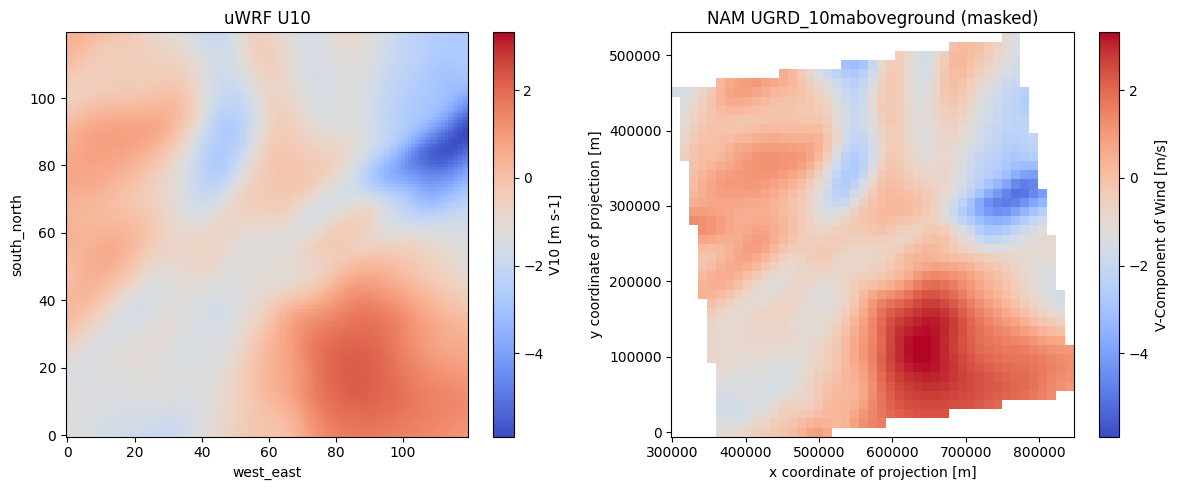

In [8]:
import matplotlib.pyplot as plt
import numpy as np

uwrf = xr.open_dataset('/D4/data/gvaillant/uwrf/01/20/d02_files/wrfout_d02_2019-01-20_00:00:00')
nam = xr.open_dataset('/D4/data/gvaillant/NAM-2019-netcdf/01/domnys-nam_218_20190120_0000_000.nc')

# Fix NAM longitudes in-place
nam['longitude'] = (nam['longitude'] + 180) % 360 - 180
# Select the first (and only) timestep
u_uwrf = uwrf['V10'].isel(Time=0)
u_nam = nam['VGRD_10maboveground'].isel(time=0)


# Set common color scale
vmin = min(float(u_uwrf.min()), float(u_nam.min()))
vmax = max(float(u_uwrf.max()), float(u_nam.max()))


# Extract spatial bounds from uWRF
lat_min = float(u_uwrf['XLAT'].min())
lat_max = float(u_uwrf['XLAT'].max())
lon_min = float(u_uwrf['XLONG'].min())
lon_max = float(u_uwrf['XLONG'].max())

nam_lat = nam['latitude']
nam_lon = nam['longitude']

# Create a spatial mask
mask = (
    (nam_lat >= lat_min) & (nam_lat <= lat_max) &
    (nam_lon >= lon_min) & (nam_lon <= lon_max)
)

u_nam_masked = u_nam.where(mask, drop=True)


import matplotlib.pyplot as plt

u_uwrf = uwrf['V10'].isel(Time=0)



# Match vmin/vmax
vmin = min(float(u_uwrf.min()), float(u_nam_masked.min()))
vmax = max(float(u_uwrf.max()), float(u_nam_masked.max()))

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

u_uwrf.plot(ax=axs[0], vmin=vmin, vmax=vmax, cmap='coolwarm')
axs[0].set_title("uWRF U10")

u_nam_masked.plot(ax=axs[1], vmin=vmin, vmax=vmax, cmap='coolwarm')
axs[1].set_title("NAM UGRD_10maboveground (masked)")

plt.tight_layout()
plt.show()



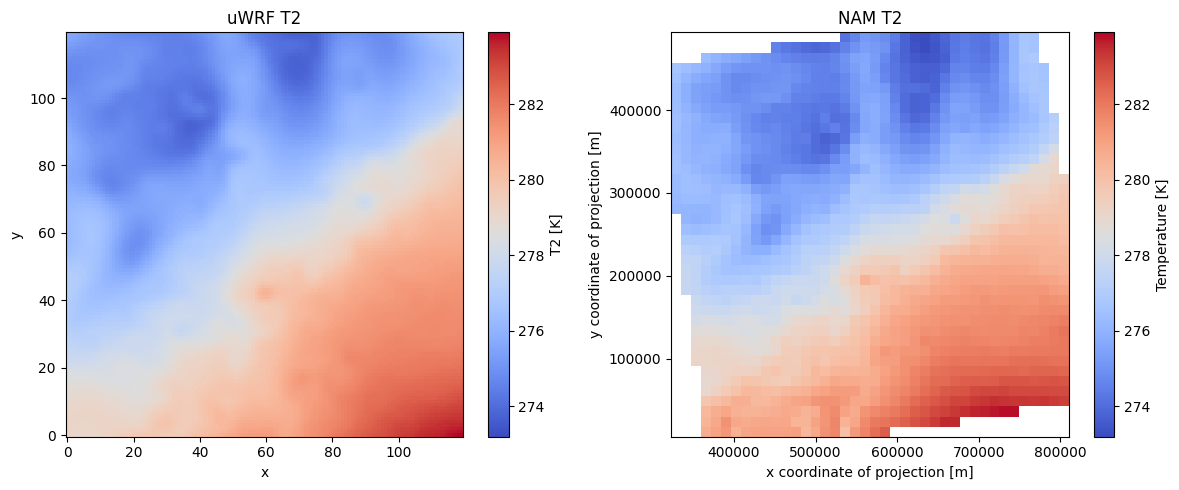

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

# Select the first (and only) timestep
u_uwrf = uwrf_train['T2'].isel(time=0)
u_nam = nam_train['T2'].isel(time=0)


# Set common color scale
vmin = min(float(u_uwrf.min()), float(u_nam.min()))
vmax = max(float(u_uwrf.max()), float(u_nam.max()))


# Extract spatial bounds from uWRF
lat_min = float(u_uwrf['latitude'].min())
lat_max = float(u_uwrf['latitude'].max())
lon_min = float(u_uwrf['longitude'].min())
lon_max = float(u_uwrf['longitude'].max())

nam_lat = nam_train['latitude']
nam_lon = nam_train['longitude']

# Create a spatial mask
mask = (
    (nam_lat >= lat_min) & (nam_lat <= lat_max) &
    (nam_lon >= lon_min) & (nam_lon <= lon_max)
)

u_nam_masked = u_nam.where(mask, drop=True)


import matplotlib.pyplot as plt

u_uwrf = uwrf_train['T2'].isel(time=0)



# Match vmin/vmax
vmin = min(float(u_uwrf.min()), float(u_nam_masked.min()))
vmax = max(float(u_uwrf.max()), float(u_nam_masked.max()))

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

u_uwrf.plot(ax=axs[0], vmin=vmin, vmax=vmax, cmap='coolwarm')
axs[0].set_title("uWRF T2")

u_nam_masked.plot(ax=axs[1], vmin=vmin, vmax=vmax, cmap='coolwarm')
axs[1].set_title("NAM T2")


plt.tight_layout()
plt.show()


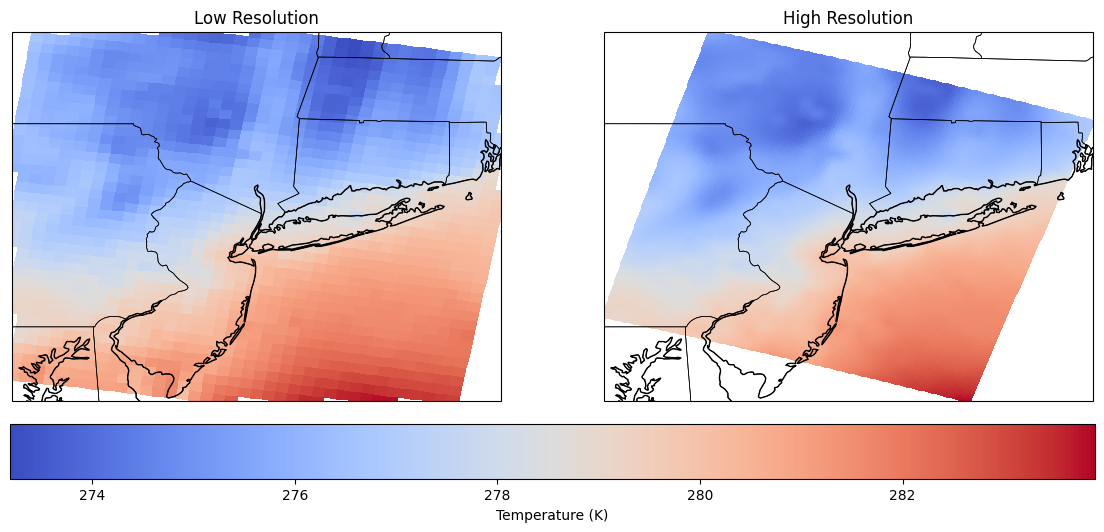

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load datasets
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')

# Select the first timestep
u_uwrf = uwrf_train['T2'].isel(time=0)
u_nam = nam_train['T2'].isel(time=0)

# Extract bounds
lat_min = float(u_uwrf['latitude'].min())
lat_max = float(u_uwrf['latitude'].max())
lon_min = float(u_uwrf['longitude'].min())
lon_max = float(u_uwrf['longitude'].max())

# Mask NAM to match uWRF region
nam_lat = nam_train['latitude']
nam_lon = nam_train['longitude']
mask = (
    (nam_lat >= lat_min) & (nam_lat <= lat_max) &
    (nam_lon >= lon_min) & (nam_lon <= lon_max)
)
u_nam_masked = u_nam.where(mask, drop=True)

# Set color scale
vmin = min(float(u_uwrf.min()), float(u_nam_masked.min()))
vmax = max(float(u_uwrf.max()), float(u_nam_masked.max()))

# Create plots with Cartopy
fig, axs = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# uWRF Plot
pc1 = axs[1].pcolormesh(u_uwrf['longitude'], u_uwrf['latitude'], u_uwrf,
                        cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axs[1].set_title("High Resolution")
axs[1].add_feature(cfeature.COASTLINE)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
axs[1].add_feature(cfeature.STATES, linewidth=0.5)


# NAM Plot
pc2 = axs[0].pcolormesh(u_nam_masked['longitude'], u_nam_masked['latitude'], u_nam_masked,
                        cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axs[0].set_title("Low Resolution")
axs[0].add_feature(cfeature.COASTLINE)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
axs[0].add_feature(cfeature.STATES, linewidth=0.5)


# Colorbar
cbar = fig.colorbar(pc1, ax=axs, orientation='horizontal', pad=0.05, label='Temperature (K)')


plt.show()
